In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')

df.columns = df.columns.str.strip().str.lower()

df['date'] = pd.to_datetime(df['date'])

# Preview the data
print(df.info())
print(df.head())

C:\Users\user\AppData\Local\Temp\ipykernel_18368\1573451629.py:7: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   region                                   267 non-null    object        
 1   date                                     267 non-null    datetime64[ns]
 2   frequency                                267 non-null    object        
 3   estimated unemployment rate (%)          267 non-null    float64       
 4   estimated employed                       267 non-null    int64         
 5   estimated labour participation rate (%)  267 non-null    float64       
 6   region.1                                 267 non-null    object        
 7   longitude                                267 non-null    float64       
 8   latitude                                 267 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1), 

In [15]:
import pandas as pd

# 1. Load the data
df = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')

# 2. Drop any completely empty rows (very common in this dataset)
df = df.dropna()

# 3. Clean column names
df.columns = df.columns.str.strip()

# 4. The "Safe" Date Conversion
# errors='coerce' turns bad dates into 'NaT' instead of crashing
# We then drop those NaT rows to keep the data clean
df['Date'] = pd.to_datetime(df['Date'].astype(str).str.strip(), dayfirst=True, errors='coerce')
df = df.dropna(subset=['Date'])

print("Dates converted successfully!")
print(df['Date'].head())

Dates converted successfully!
0   2020-01-31
1   2020-02-29
2   2020-03-31
3   2020-04-30
4   2020-05-31
Name: Date, dtype: datetime64[ns]


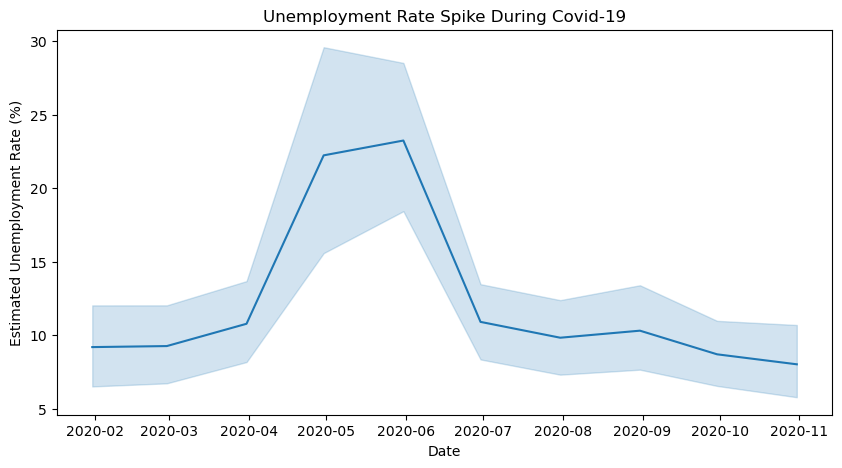

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)')
plt.title('Unemployment Rate Spike During Covid-19')
plt.show()

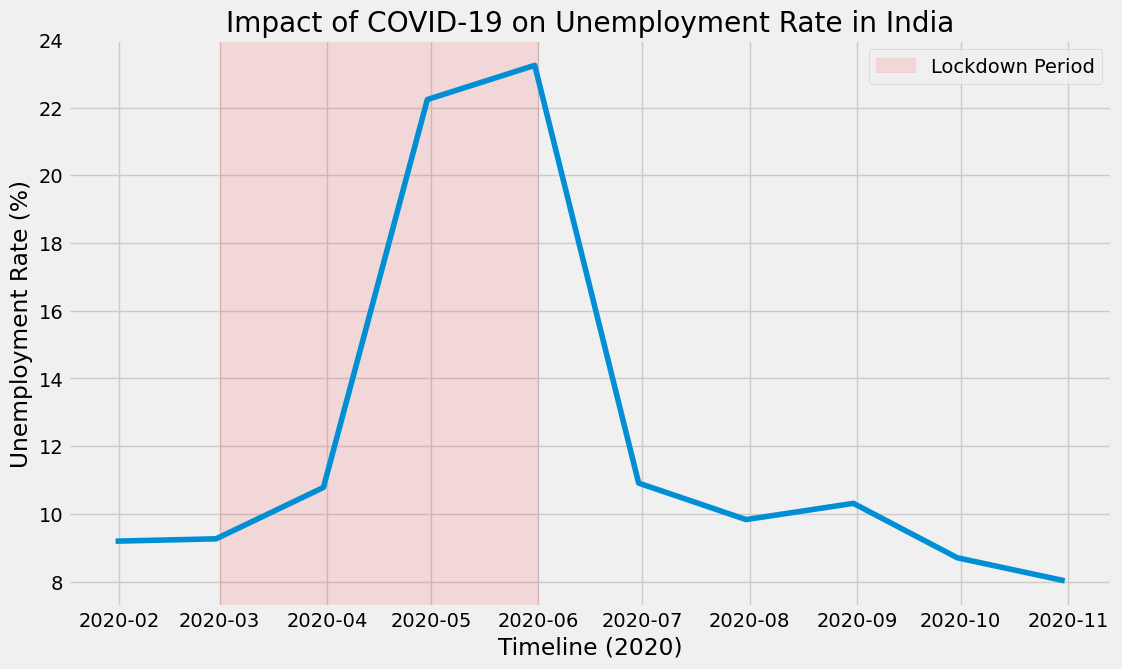

In [18]:
# Set a professional style
plt.style.use('fivethirtyeight')
plt.figure(figsize=(12, 7))

# Plotting the data
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', errorbar=None)

# Highlight the Covid-19 Lockdowns (Approx. March - June 2020)
plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2020-06-01'), color='red', alpha=0.1, label='Lockdown Period')

plt.title('Impact of COVID-19 on Unemployment Rate in India')
plt.xlabel('Timeline (2020)')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_18368\964732928.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




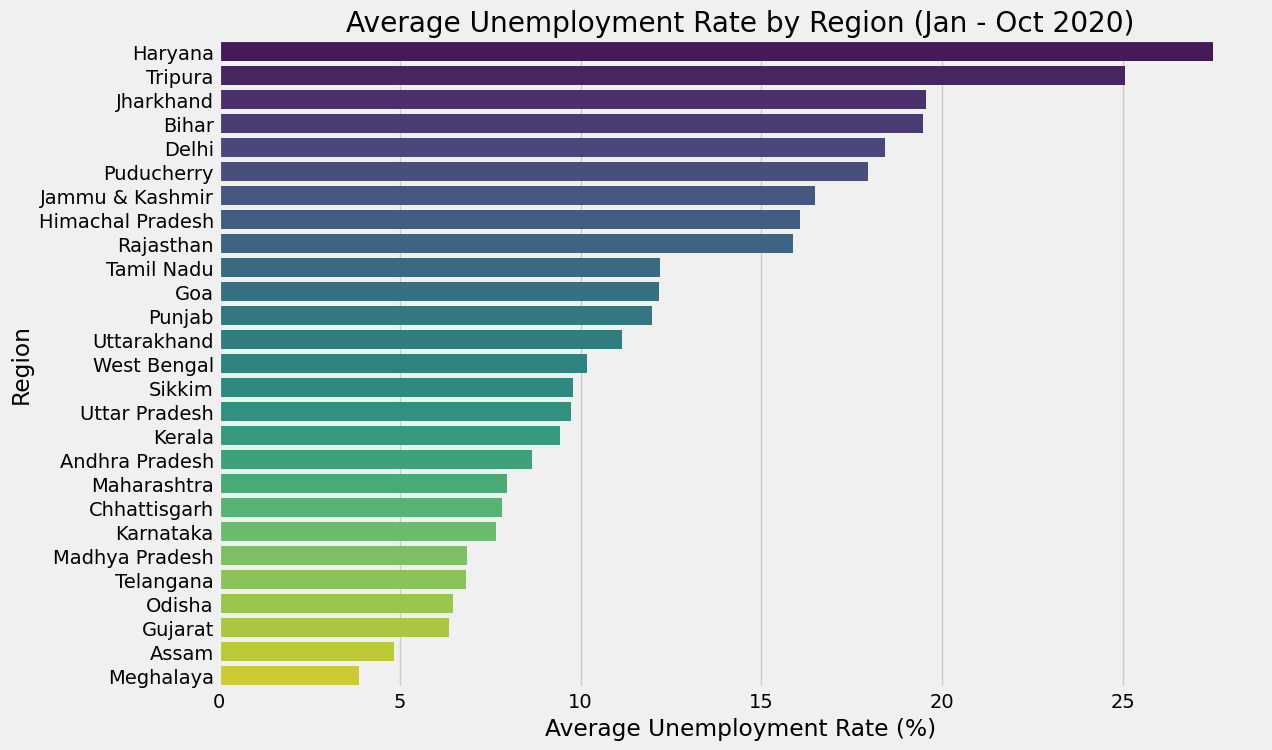

In [19]:
# Calculate average rate per region
region_stats = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=region_stats, x='Estimated Unemployment Rate (%)', y='Region', palette='viridis')

plt.title('Average Unemployment Rate by Region (Jan - Oct 2020)')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('Region')
plt.show()